In [ ]:
from datasets import load_dataset

meta_data = load_dataset("mvasil/polyvore-outfits", "disjoint", split="train", streaming=True, token="")


In [7]:
from PIL import Image

meta_data = meta_data.cast_column("image", Image(mode="RGB"))

TypeError: 'module' object is not callable

In [3]:
import os
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image


class FashionDataset(Dataset):
    def __init__(self, image_dir, labels_csv, transform=None):
        self.img_dir = image_dir
        self.labels_df = pd.read_csv(labels_csv, on_bad_lines="skip")
        self.transform = transform

    def __len__(self):
        return self.labels_df.shape[0] 

    def __getitem__(self, idx):
        # 1. Get the filename (e.g., id + .jpg)
        img_name = str(self.labels_df.iloc[idx]['id']) + ".jpg"
        # 2. Get the labels (subCategory, baseColour, articleType)
        sub_category = self.labels_df.iloc[idx]['subCategory']
        base_colour = self.labels_df.iloc[idx]['baseColour']
        article_type = self.labels_df.iloc[idx]['articleType']
        # 3. Load the image
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        # 4. Apply transforms (like resizing or ToTensor)
        if self.transform:
            image = self.transform(image)
            
        return image, sub_category, base_colour, article_type

In [78]:
from torchvision import transforms

my_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [79]:
dataset = FashionDataset(image_dir="dataset/images", labels_csv="dataset/styles.csv", transform=my_transform)

In [ ]:
dataset.

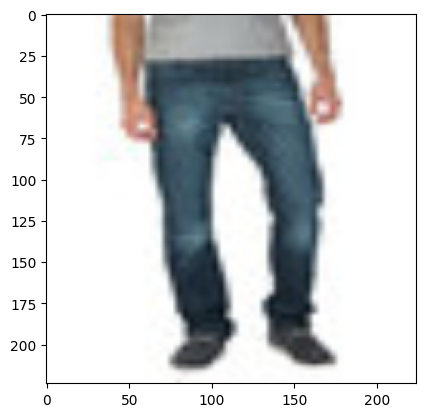

In [68]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

index = np.random.randint(0, high=len(dataset))
img_to_show = dataset[1][0].permute(1,2,0).cpu().numpy()

plt.imshow(img_to_show)

In [72]:
label_sample = dataset[1][2]
label_sample

'Blue'

In [88]:
import torch

device = torch.device(torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [ ]:
train_set, val_set = torch.utils.data.random_split(dataset, [int(0.8*len(dataset)), int(0.2*len(dataset)) + 1])

In [2]:
from torch.utils.data import DataLoader

batch_size = 64

train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

NameError: name 'train_set' is not defined